In [6]:
# --- CatBoost on the CURRENT feature set (same tree_ready data as every other model) ---
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')
X_test  = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_train = pd.read_pickle('../data/processed/tree_ready/y_train.pkl')
y_test  = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')

spw = (y_train == 0).sum() / (y_train == 1).sum()
cat = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                         scale_pos_weight=spw, random_state=42, verbose=0)
cat.fit(X_train, y_train)

proba = cat.predict_proba(X_test)[:, 1]
pred  = cat.predict(X_test)
catboost_row = pd.DataFrame([{
    'model': 'CatBoost',
    'accuracy':  accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred, zero_division=0),
    'recall':    recall_score(y_test, pred),
    'f1':        f1_score(y_test, pred),
    'auc':       roc_auc_score(y_test, proba),
}])
catboost_row.to_csv('../results/metrics/catboost_metrics.csv', index=False)
print(catboost_row)

      model  accuracy  precision    recall        f1       auc
0  CatBoost  0.693333   0.513761  0.525822  0.519722  0.684125


In [7]:
baseline = pd.read_csv('../results/metrics/baseline_metrics.csv')
ensemble = pd.read_csv('../results/metrics/ensemble_ml_metrics.csv')
boosting = pd.read_csv('../results/metrics/boosting_metrics.csv')
stacking = pd.read_csv('../results/metrics/stacking_metrics.csv')
catboost = pd.read_csv('../results/metrics/catboost_metrics.csv')   # <-- NEW

all_results = pd.concat([baseline, ensemble, boosting, stacking, catboost],
                        ignore_index=True)
all_results = all_results.drop_duplicates(subset='model', keep='last')
all_results = all_results.sort_values('recall', ascending=False)
print(all_results)

all_results.to_csv('../results/metrics/all_models_comparison.csv', index=False)

                                       model  accuracy  precision    recall  \
4                                        SVM  0.675556   0.488000  0.572770   
0                        Logistic Regression  0.672593   0.484000  0.568075   
5       Logistic Regression (L1 Regularized)  0.672593   0.484000  0.568075   
10                       LightGBM (from 05b)  0.688889   0.506383  0.558685   
15                     LightGBM (standalone)  0.688889   0.506383  0.558685   
7                                   LightGBM  0.688889   0.506383  0.558685   
14                      XGBoost (standalone)  0.722963   0.561905  0.553991   
11                                  AdaBoost  0.705185   0.531532  0.553991   
12  Stacking Ensemble (RF+XGB+LGBM → LogReg)  0.699259   0.522321  0.549296   
8                                    XGBoost  0.715556   0.549296  0.549296   
9                         XGBoost (from 05b)  0.715556   0.549296  0.549296   
6                              Random Forest  0.7096

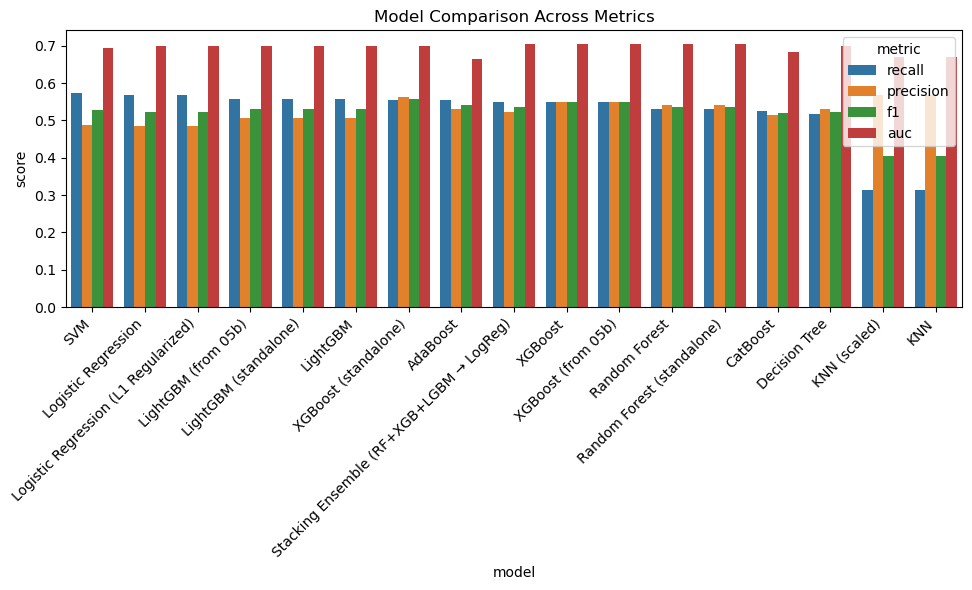

In [8]:
# Cell 2 — comparison chart
plt.figure(figsize=(10, 6))
melted = all_results.melt(id_vars='model', value_vars=['recall', 'precision', 'f1', 'auc'],
                            var_name='metric', value_name='score')
sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

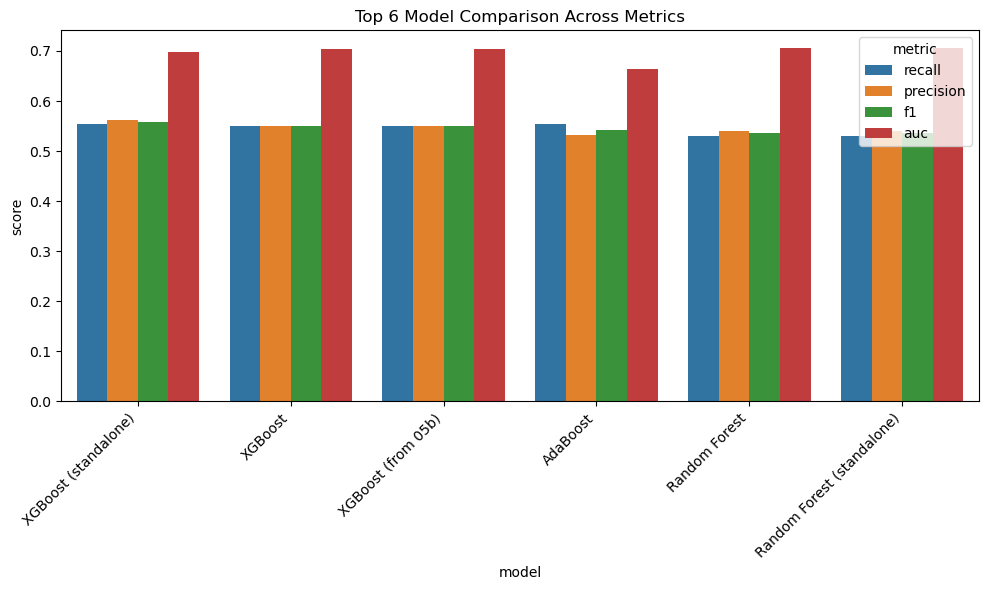

In [9]:
# Cell 2 — comparison chart (Top 6 Models)
plt.figure(figsize=(10, 6))

# Filter for the top 6 models based on F1 score (change 'f1' to 'auc' or another metric if preferred)
top_6_models = all_results.nlargest(6, 'f1')

# Melt the top 6 dataset
melted = top_6_models.melt(
    id_vars='model', 
    value_vars=['recall', 'precision', 'f1', 'auc'],
    var_name='metric', 
    value_name='score'
)

sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=45, ha='right')
plt.title('Top 6 Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

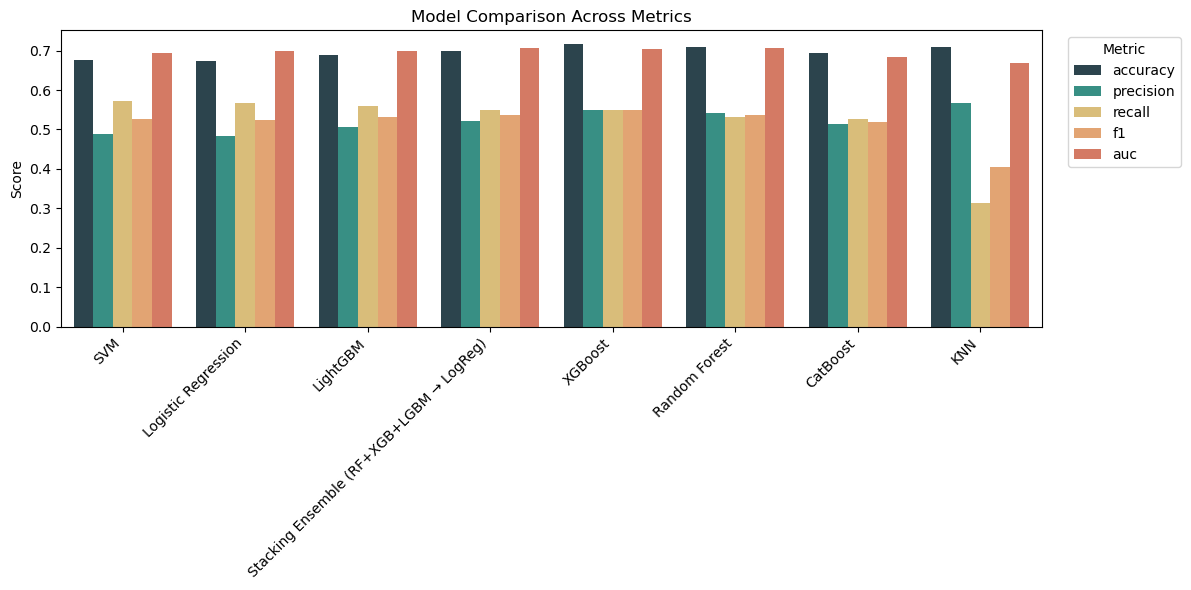

In [10]:
#top 6 model counting xgboost,xgboost stanadlone as one like that
# Cell 2 — comparison chart (models in table only, editorial palette)
plt.figure(figsize=(12, 6))
STACKING_MODEL_NAME = 'Stacking Ensemble (RF+XGB+LGBM → LogReg)'
models_to_show = [
    STACKING_MODEL_NAME,
    'XGBoost',
    'CatBoost',            # <-- NEW
    'Random Forest',
    'LightGBM',
    'KNN',
    'Logistic Regression',
    'SVM',
]

filtered_results = all_results[all_results['model'].isin(models_to_show)]

melted = filtered_results.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    var_name='metric',
    value_name='score'
)

palette = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

sns.barplot(data=melted, x='model', y='score', hue='metric', palette=palette)
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
# Cell 3 — identify best model
best_row = all_results.iloc[0]
print(f"Best model by recall: {best_row['model']} (recall={best_row['recall']:.3f}, AUC={best_row['auc']:.3f})")

Best model by recall: SVM (recall=0.573, AUC=0.693)
